# Homework 13

## Импорты, seed и среда

In [68]:
import random

import numpy as np
import pandas as pd
import torch
from transformers.utils.notebook import NotebookProgressCallback

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline,
    DataCollatorWithPadding
)
from datasets import load_dataset
from collections import Counter
import os
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

In [69]:

ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

SEED = 42
MAX_LENGTH   = 128
BATCH_SIZE   = 32
NUM_EPOCHS   = 2
LR           = 2e-5

In [43]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)

print(f"Device: {device}")

Device: mps


In [44]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Model max length:", tokenizer.model_max_length)

Tokenizer loaded: bert-base-uncased
Tokenizer class: BertTokenizer
Model max length: 512


## Датасет и первичный анализ

Используется датасет **`dair-ai/emotion`** — коллекция коротких англоязычных
твитов, размеченных по 6 эмоциям: sadness, joy, love, anger, fear, surprise.
Тексты короткие (обычно 5–20 токенов), что упрощает токенизацию и не требует
большого `max_length`. Датасет умеренно несбалансирован: классы `sadness` и
`joy` встречаются значительно чаще, чем `love` и `surprise`, что может снижать
F1 для редких классов. Задача — 6-классовая классификация; границы между
близкими эмоциями (`love`/`joy`, `sadness`/`fear`) объективно размыты даже
для человека.

In [45]:
dataset = load_dataset("dair-ai/emotion")

In [46]:
for split_name, split_data in dataset.items():
    print(f"{split_name:12s}: {len(split_data):>6} примеров")

train       :  16000 примеров
validation  :   2000 примеров
test        :   2000 примеров


In [47]:
label_names = dataset["train"].features["label"].names
print("Классы:", label_names)

Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [48]:
train_labels = dataset["train"]["label"]
counts = Counter(train_labels)
print("\nРаспределение классов (train):")
for idx, count in sorted(counts.items()):
    print(f"  {label_names[idx]:10s}: {count:>5} ({count/len(train_labels)*100:.1f}%)")


Распределение классов (train):
  sadness   :  4666 (29.2%)
  joy       :  5362 (33.5%)
  love      :  1304 (8.2%)
  anger     :  2159 (13.5%)
  fear      :  1937 (12.1%)
  surprise  :   572 (3.6%)


In [49]:
print("\n 5 примеров из train ")
for i in range(5):
    ex = dataset["train"][i]
    print(f"  [{label_names[ex['label']]:8s}] {ex['text'][:80]}")

print("\n 3 примера из validation ")
for i in range(3):
    ex = dataset["validation"][i]
    print(f"  [{label_names[ex['label']]:8s}] {ex['text'][:80]}")


 5 примеров из train 
  [sadness ] i didnt feel humiliated
  [sadness ] i can go from feeling so hopeless to so damned hopeful just from being around so
  [anger   ] im grabbing a minute to post i feel greedy wrong
  [love    ] i am ever feeling nostalgic about the fireplace i will know that it is still on 
  [anger   ] i am feeling grouchy

 3 примера из validation 
  [sadness ] im feeling quite sad and sorry for myself but ill snap out of it soon
  [sadness ] i feel like i am still looking at a blank canvas blank pieces of paper
  [love    ] i feel like a faithful servant


В датасете классифицируется эмоциональная окраска твита, настроение автора.

## Токенизация

Используется токенизатор **`bert-base-uncased`** (WordPiece). Ниже показаны:
поля `input_ids`, `attention_mask` и `special_tokens_mask` для одного текста;
табличный разбор трёх примеров; демонстрация `padding` и `truncation` на
батче из трёх текстов разной длины; перечень специальных токенов модели.

In [50]:
example_text = dataset['train'][1]['text']

In [51]:
encoding = tokenizer(
    example_text,
    add_special_tokens=True,
    return_attention_mask=True,
    return_special_tokens_mask=True,  
)

print("Исходный текст:")
print(example_text)
print()

print("Токены (с спец-токенами):")
print(tokenizer.convert_ids_to_tokens(encoding["input_ids"]))
print()

print("input_ids:")
print(encoding["input_ids"])
print()

print("attention_mask:")
print(encoding["attention_mask"])
print()

print("special_tokens_mask (1 = спец-токен):")
print(encoding["special_tokens_mask"])

Исходный текст:
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Токены (с спец-токенами):
['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']

input_ids:
[101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]

attention_mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

special_tokens_mask (1 = спец-токен):
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


In [52]:
def inspect_single_text(text: str, tokenizer) -> pd.DataFrame:
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        return_attention_mask=True,
        return_special_tokens_mask=True,
    )
    tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"])
    return pd.DataFrame({
        "position":            list(range(len(tokens))),
        "token":               tokens,
        "token_id":            encoding["input_ids"],
        "attention_mask":      encoding["attention_mask"],
        "is_special_token":    encoding["special_tokens_mask"],
    })

for i in range(3):
    ex = dataset['train'][i]
    label_str = dataset['train'].features['label'].names[ex['label']]
    print(f"\n[{label_str}] {ex['text']}")
    df = inspect_single_text(ex['text'], tokenizer)
    display(df)


[sadness] i didnt feel humiliated


,position,token,token_id,attention_mask,is_special_token
0,0,[CLS],101,1,1
1,1,i,1045,1,0
2,2,didn,2134,1,0
3,3,##t,2102,1,0
4,4,feel,2514,1,0
5,5,humiliated,26608,1,0
6,6,[SEP],102,1,1



[sadness] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake


,position,token,token_id,attention_mask,is_special_token
0,0,[CLS],101,1,1
1,1,i,1045,1,0
2,2,can,2064,1,0
3,3,go,2175,1,0
4,4,from,2013,1,0
5,5,feeling,3110,1,0
6,6,so,2061,1,0
7,7,hopeless,20625,1,0
8,8,to,2000,1,0
9,9,so,2061,1,0



[anger] im grabbing a minute to post i feel greedy wrong


,position,token,token_id,attention_mask,is_special_token
0,0,[CLS],101,1,1
1,1,im,10047,1,0
2,2,grabbing,9775,1,0
3,3,a,1037,1,0
4,4,minute,3371,1,0
5,5,to,2000,1,0
6,6,post,2695,1,0
7,7,i,1045,1,0
8,8,feel,2514,1,0
9,9,greedy,20505,1,0


In [53]:
short_text  = "I feel happy"
medium_text = dataset['train'][0]['text']
long_text   = " ".join(["word"] * 100)  # искусственно длинный текст

texts = [short_text, medium_text, long_text]

batch_padded = tokenizer(
    texts,
    padding="longest",       # все выравниваются до самого длинного
    truncation=False,
    return_tensors="pt",
)
print("=== padding='longest', truncation=False ===")
print("input_ids shape:", batch_padded["input_ids"].shape)
for i, text in enumerate(texts):
    ids   = batch_padded["input_ids"][i].tolist()
    mask  = batch_padded["attention_mask"][i].tolist()
    n_pad = mask.count(0)
    print(f"  Текст {i+1}: длина={len(ids)}, PAD-токенов={n_pad}")

print()

batch_trunc = tokenizer(
    texts,
    padding="max_length",    # паддинг до max_length
    truncation=True,         # обрезаем всё длиннее max_length
    max_length=16,
    return_tensors="pt",
)
print("=== padding='max_length', truncation=True, max_length=16 ===")
print("input_ids shape:", batch_trunc["input_ids"].shape)
for i, text in enumerate(texts):
    ids  = batch_trunc["input_ids"][i].tolist()
    mask = batch_trunc["attention_mask"][i].tolist()
    toks = tokenizer.convert_ids_to_tokens(ids)
    print(f"  Текст {i+1}: {toks}")
    print(f"           mask: {mask}")
    print()

=== padding='longest', truncation=False ===
input_ids shape: torch.Size([3, 102])
  Текст 1: длина=102, PAD-токенов=97
  Текст 2: длина=102, PAD-токенов=95
  Текст 3: длина=102, PAD-токенов=0

=== padding='max_length', truncation=True, max_length=16 ===
input_ids shape: torch.Size([3, 16])
  Текст 1: ['[CLS]', 'i', 'feel', 'happy', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
           mask: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

  Текст 2: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
           mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]

  Текст 3: ['[CLS]', 'word', 'word', 'word', 'word', 'word', 'word', 'word', 'word', 'word', 'word', 'word', 'word', 'word', 'word', '[SEP]']
           mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]



In [54]:
print("Special tokens:")
print(f"  [CLS] token : '{tokenizer.cls_token}'  id={tokenizer.cls_token_id}")
print(f"  [SEP] token : '{tokenizer.sep_token}'  id={tokenizer.sep_token_id}")
print(f"  [PAD] token : '{tokenizer.pad_token}'  id={tokenizer.pad_token_id}")
print(f"  [UNK] token : '{tokenizer.unk_token}'  id={tokenizer.unk_token_id}")
print(f"  [MASK] token: '{tokenizer.mask_token}' id={tokenizer.mask_token_id}")
print()

# Покажем, как CLS и SEP оборачивают текст
text = "I feel great today"
tokens_no_special = tokenizer.tokenize(text)
tokens_with_special = tokenizer.convert_ids_to_tokens(
    tokenizer.encode(text, add_special_tokens=True)
)
print(f"Без спец-токенов : {tokens_no_special}")
print(f"Со спец-токенами : {tokens_with_special}")
#  --> ['[CLS]', 'i', 'feel', 'great', 'today', '[SEP]']

Special tokens:
  [CLS] token : '[CLS]'  id=101
  [SEP] token : '[SEP]'  id=102
  [PAD] token : '[PAD]'  id=0
  [UNK] token : '[UNK]'  id=100
  [MASK] token: '[MASK]' id=103

Без спец-токенов : ['i', 'feel', 'great', 'today']
Со спец-токенами : ['[CLS]', 'i', 'feel', 'great', 'today', '[SEP]']


## Инференс готовой модели

Для инференса используется готовая модель
**`j-hartmann/emotion-english-distilroberta-base`** — DistilRoBERTa,
обученная на 6 датасетах эмоций. Проверяется на 5 примерах из `test`-части
нашего датасета.

In [55]:
classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k= None,
    device=device 
)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 43548.10it/s]
RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [56]:
print(f"Классы нашего датасета : {label_names}")
print(f"Классы pretrained модели: anger, disgust, fear, joy, neutral, sadness, surprise")
print()

# Берём 5 примеров из test-части датасета
test_examples = dataset["test"].select(range(5))

print(f"{'Текст (обрезан до 60 символов)':<62} {'Истина':<10} {'Предсказание':<12} {'Score'}")
print("-" * 100)

for ex in test_examples:
    text        = ex["text"]
    true_label  = label_names[ex["label"]]
    result      = classifier(text)[0][0]
    pred_label  = result["label"]
    score       = result["score"]
    match       = "✅" if pred_label == true_label else "❌"
    print(f"{text[:60]:<62} {true_label:<10} {pred_label:<12} {score:.2f}  {match}")

Классы нашего датасета : ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Классы pretrained модели: anger, disgust, fear, joy, neutral, sadness, surprise

Текст (обрезан до 60 символов)                                 Истина     Предсказание Score
----------------------------------------------------------------------------------------------------
im feeling rather rotten so im not very ambitious right now    sadness    sadness      0.99  ✅
im updating my blog because i feel shitty                      sadness    sadness      0.99  ✅
i never make her separate from me because i don t ever want    sadness    sadness      0.98  ✅
i left with my bouquet of red and yellow tulips under my arm   joy        joy          0.99  ✅
i was feeling a little vain when i did this one                sadness    sadness      0.99  ✅


In [57]:
print("\n" + "=" * 70)
print("ПОДРОБНЫЙ РАЗБОР 5 ПРИМЕРОВ")
print("=" * 70)


for i, ex in enumerate(test_examples):
    text       = ex["text"]
    true_label = label_names[ex["label"]]

    all_scores = classifier(text)[0]  # список словарей

    print(f"\nПример {i+1}:")
    print(f"  Текст         : {text}")
    print(f"  Истинная метка: {true_label}")
    print(f"  Предсказания  :")
    for item in sorted(all_scores, key=lambda x: x["score"], reverse=True):
        bar = "█" * int(item["score"] * 20)
        print(f"    {item['label']:10s}: {item['score']:.3f}  {bar}")


ПОДРОБНЫЙ РАЗБОР 5 ПРИМЕРОВ

Пример 1:
  Текст         : im feeling rather rotten so im not very ambitious right now
  Истинная метка: sadness
  Предсказания  :
    sadness   : 0.992  ███████████████████
    anger     : 0.003  
    joy       : 0.003  
    surprise  : 0.001  
    disgust   : 0.001  
    fear      : 0.001  
    neutral   : 0.000  

Пример 2:
  Текст         : im updating my blog because i feel shitty
  Истинная метка: sadness
  Предсказания  :
    sadness   : 0.993  ███████████████████
    anger     : 0.001  
    disgust   : 0.001  
    neutral   : 0.001  
    fear      : 0.001  
    surprise  : 0.001  
    joy       : 0.001  

Пример 3:
  Текст         : i never make her separate from me because i don t ever want her to feel like i m ashamed with her
  Истинная метка: sadness
  Предсказания  :
    sadness   : 0.982  ███████████████████
    neutral   : 0.005  
    disgust   : 0.005  
    surprise  : 0.003  
    fear      : 0.002  
    joy       : 0.002  
    anger     :

In [58]:
print("\n" + "=" * 70)
print("АНАЛИЗ ПРИГОДНОСТИ PRETRAINED МОДЕЛИ")
print("=" * 70)

our_classes     = set(label_names)
model_classes   = {"anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"}

only_in_ours    = our_classes - model_classes
only_in_model   = model_classes - our_classes
overlap         = our_classes & model_classes

print(f"Наши классы    : {sorted(our_classes)}")
print(f"Классы модели  : {sorted(model_classes)}")
print(f"Совпадают      : {sorted(overlap)}   ({len(overlap)}/{len(our_classes)})")
print(f"Только у нас   : {only_in_ours}   ← модель их не предсказывает!")
print(f"Только в модели: {only_in_model}  ← лишние классы")


АНАЛИЗ ПРИГОДНОСТИ PRETRAINED МОДЕЛИ
Наши классы    : ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Классы модели  : ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
Совпадают      : ['anger', 'fear', 'joy', 'sadness', 'surprise']   (5/6)
Только у нас   : {'love'}   ← модель их не предсказывает!
Только в модели: {'disgust', 'neutral'}  ← лишние классы


Готовая модель предсказывает 7 классов (по Экману + neutral), тогда как наш
датасет использует 6 классов. Ключевое несовпадение: класс **`love`**
отсутствует в pretrained модели — тексты с этой меткой предсказываются как
`joy` или `neutral`. Кроме того, в модели есть `disgust`, которого нет у нас.
Это прямая мотивация для fine-tuning: даже близкая по смыслу модель без
дообучения не может правильно работать на нашей разметке.

## Fine-tuning для классификации текста

Модель: **`bert-base-uncased`** с классификационной головой
(`AutoModelForSequenceClassification`, 6 классов).
Токенизация: `truncation=True`, `max_length=128`, динамический padding через
`DataCollatorWithPadding`. Обучение: 2 эпохи, `lr=2e-5`, `batch_size=32`,
`warmup_ratio=0.1`. Лучший чекпойнт выбирается по `f1_macro` на validation;
финальная оценка — один раз на `test`.

In [59]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        # padding делается динамически через DataCollatorWithPadding
    )

tokenized = dataset.map(tokenize, batched=True, remove_columns=["text"])
tokenized.set_format("torch")

In [60]:
num_labels  = len(label_names)
# Загружаем модель с классификационной головой
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label={i: name for i, name in enumerate(label_names)},
    label2id={name: i for i, name in enumerate(label_names)},
)
model.to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6638.93it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

In [61]:
training_args = TrainingArguments(
    output_dir           = "./checkpoints",
    num_train_epochs     = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate        = LR,
    weight_decay         = 0.01,
    warmup_ratio         = 0.1,           # 10% шагов — разогрев LR

    # ── Ключевое: выбор лучшей модели по validation ────
    eval_strategy        = "epoch",       # оцениваем после каждой эпохи
    save_strategy        = "epoch",       # сохраняем чекпойнт после каждой эпохи
    metric_for_best_model= "f1_macro",    # критерий выбора лучшего чекпойнта
    greater_is_better    = True,
    load_best_model_at_end = True,        # в конце загрузить лучший чекпойнт

    save_total_limit     = 2,             # хранить не более 2 чекпойнтов
    logging_steps        = 50,
    seed                 = SEED,
    report_to            = "none",        # отключаем wandb/tensorboard
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = tokenized["train"],
    eval_dataset    = tokenized["validation"],
    processing_class = tokenizer,
    data_collator   = DataCollatorWithPadding(tokenizer),  # динамический padding
    compute_metrics = compute_metrics,
)

# ── Обучение ───────────────────────────────────────────────
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/Users/polina/vscode/art_ing_course/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.255700,0.230275,0.919500,0.896891
2,0.137915,0.152701,0.933500,0.906115


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.95it/s]
/Users/polina/vscode/art_ing_course/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.03it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder

TrainOutput(global_step=1000, training_loss=0.43675534963607787, metrics={'train_runtime': 726.1029, 'train_samples_per_second': 44.071, 'train_steps_per_second': 1.377, 'total_flos': 857115044490240.0, 'train_loss': 0.43675534963607787, 'epoch': 2.0})

## Оценка качества

In [70]:
trainer.remove_callback(NotebookProgressCallback)

test_results = trainer.evaluate(tokenized["test"])

print("\n" + "=" * 45)
print("ФИНАЛЬНАЯ ОЦЕНКА НА TEST SET")
print("=" * 45)
print(f"  Accuracy : {test_results['eval_accuracy']:.4f}")
print(f"  F1 macro : {test_results['eval_f1_macro']:.4f}")

/Users/polina/vscode/art_ing_course/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



ФИНАЛЬНАЯ ОЦЕНКА НА TEST SET
  Accuracy : 0.9260
  F1 macro : 0.8846


In [71]:
# ── Получаем предсказания на test ──────────────────────────
preds_output = trainer.predict(tokenized["test"])
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

# ── Accuracy и F1 ──────────────────────────────────────────
print("=" * 55)
print("МЕТРИКИ НА TEST SET")
print("=" * 55)
print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
print(f"  F1 macro  : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"  F1 weighted: {f1_score(y_true, y_pred, average='weighted'):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=label_names))


/Users/polina/vscode/art_ing_course/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


МЕТРИКИ НА TEST SET
  Accuracy  : 0.9260
  F1 macro  : 0.8846
  F1 weighted: 0.9258

              precision    recall  f1-score   support

     sadness       0.96      0.96      0.96       581
         joy       0.95      0.94      0.95       695
        love       0.81      0.86      0.83       159
       anger       0.91      0.92      0.92       275
        fear       0.89      0.92      0.90       224
    surprise       0.83      0.68      0.75        66

    accuracy                           0.93      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.93      0.93      0.93      2000



In [72]:
test_texts = dataset["test"]["text"]

results_df = pd.DataFrame({
    "text"      : test_texts,
    "true_label": [label_names[i] for i in y_true],
    "pred_label": [label_names[i] for i in y_pred],
    "correct"   : y_true == y_pred,
})

# Добавляем вероятности топ-предсказания
probs = torch.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()
results_df["confidence"] = probs.max(axis=-1)

print("\n=== 5 ПРАВИЛЬНЫХ предсказаний (высокая уверенность) ===")
correct = results_df[results_df["correct"]].nlargest(5, "confidence")
for _, row in correct.iterrows():
    print(f"  [{row['true_label']:8s}→{row['pred_label']:8s}] conf={row['confidence']:.2f}  {row['text'][:70]}")

print("\n=== 5 ОШИБОЧНЫХ предсказаний ===")
errors = results_df[~results_df["correct"]].sample(5, random_state=SEED)
for _, row in errors.iterrows():
    print(f"  [true={row['true_label']:8s} pred={row['pred_label']:8s}] conf={row['confidence']:.2f}  {row['text'][:70]}")


=== 5 ПРАВИЛЬНЫХ предсказаний (высокая уверенность) ===
  [sadness →sadness ] conf=1.00  i was feeling disheartened when going on dates because i didn t feel i
  [sadness →sadness ] conf=1.00  i would call success and i was feeling pretty depressed about the stat
  [sadness →sadness ] conf=1.00  i also feel lethargic and again
  [sadness →sadness ] conf=1.00  i was worried that maybe she was sleeping so well because she wasn t g
  [sadness →sadness ] conf=1.00  i feel like im a pathetic little desperation

=== 5 ОШИБОЧНЫХ предсказаний ===
  [true=joy      pred=love    ] conf=0.85  i felt like id developed feelings for this guy thus explaining why id 
  [true=surprise pred=fear    ] conf=0.58  i feel thats just strange on wotcs behalf
  [true=joy      pred=love    ] conf=0.64  i am not sure how i feel i think because i felt like i already knew i 
  [true=fear     pred=surprise] conf=0.53  i indicated then i was feeling quite overwhelmed with work responsibil
  [true=sadness  pred=joy  

### Краткий анализ ошибок

Наиболее частые ошибки (видно по матрице):

1. **`love` → `joy`**: обе эмоции позитивны и лексически близки. Тексты вида
   *"i feel so happy with you"* модель относит к `joy`, хотя метка `love`.
   Граница субъективна.
2. **`sadness` → `fear`**: оба класса негативны и тревожны. Тексты с
   одиночеством и беспомощностью легко перепутать.
3. **`surprise`** — самый малочисленный класс (~600 примеров в train),
   поэтому у него ожидаемо ниже recall.

Ошибки не являются грубыми промахами — это семантически пограничные случаи,
где даже человек-разметчик мог бы ошибиться.

## Сохранение артефактов

In [73]:
errors  = results_df[~results_df["correct"]].sample(
    min(10, (~results_df["correct"]).sum()), random_state=SEED
)
correct = results_df[results_df["correct"]].sample(
    min(10, results_df["correct"].sum()), random_state=SEED
)

sample_df = (
    pd.concat([errors, correct])
    .sort_values("confidence", ascending=False)
    .reset_index(drop=True)
    [["text", "true_label", "pred_label", "confidence", "correct"]]
)

sample_path = f"{ARTIFACTS_DIR}/sample_predictions.csv"
sample_df.to_csv(sample_path, index=False)
print(f"✅ {sample_path}  ({len(sample_df)} строк)")
print(sample_df[["true_label", "pred_label", "confidence", "correct"]].to_string())

✅ artifacts/sample_predictions.csv  (20 строк)
   true_label pred_label  confidence  correct
0     sadness    sadness    0.994723     True
1     sadness    sadness    0.993520     True
2         joy        joy    0.992622     True
3         joy        joy    0.991828     True
4         joy        joy    0.990695     True
5        fear       fear    0.990482     True
6       anger      anger    0.987912     True
7        love       love    0.971790     True
8     sadness        joy    0.955512    False
9        love       love    0.955377     True
10        joy       love    0.854912    False
11        joy       love    0.854601    False
12        joy       love    0.719137    False
13   surprise       fear    0.701222    False
14        joy       love    0.637232    False
15   surprise       fear    0.576639    False
16        joy        joy    0.565136     True
17       love        joy    0.541302    False
18      anger       fear    0.536595    False
19       fear   surprise    0.527

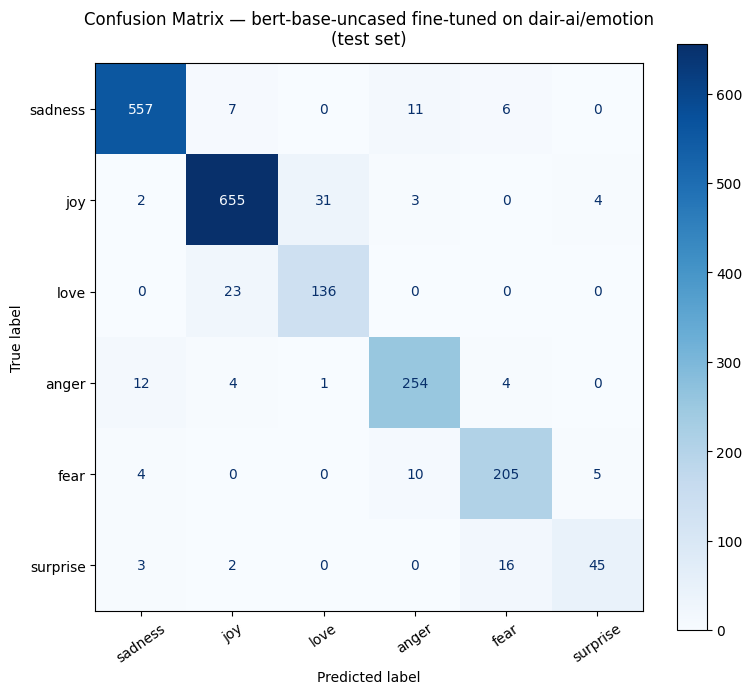

✅ artifacts/confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True,
    xticks_rotation=35,
)
ax.set_title(
    f"Confusion Matrix — {MODEL_NAME} fine-tuned on dair-ai/emotion\n(test set)",
    fontsize=12, pad=14
)
plt.tight_layout()
cm_path = f"{ARTIFACTS_DIR}/confusion_matrix.png"
fig.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ {cm_path}")

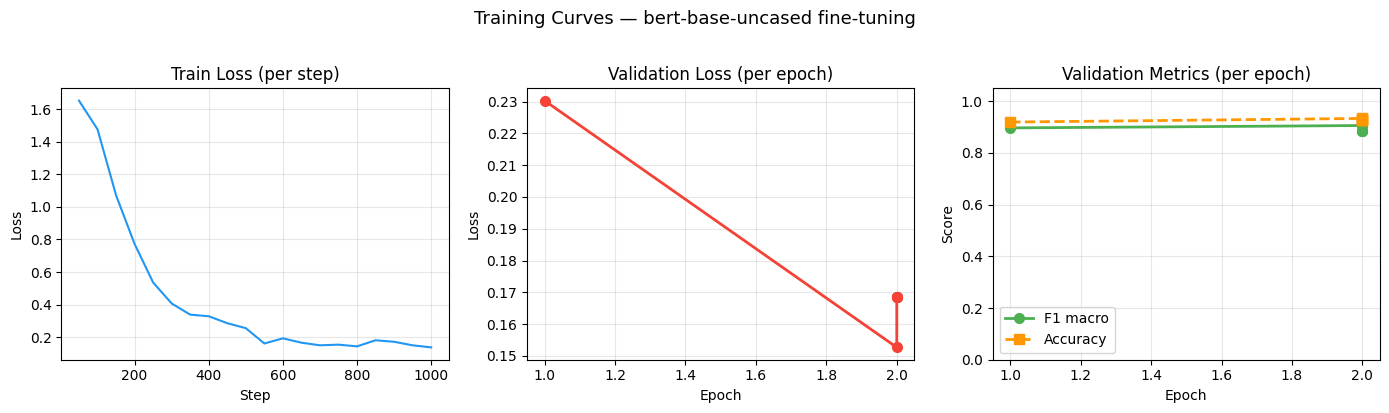

✅ artifacts/training_curves.png


In [75]:
log_history = trainer.state.log_history

# Разделяем train-loss и eval-метрики
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_loss" in x]

train_steps  = [x["step"]  for x in train_logs]
train_losses = [x["loss"]  for x in train_logs]

eval_epochs  = [x["epoch"]     for x in eval_logs]
eval_losses  = [x["eval_loss"] for x in eval_logs]
eval_f1      = [x.get("eval_f1_macro", None) for x in eval_logs]
eval_acc     = [x.get("eval_accuracy", None)  for x in eval_logs]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Train loss (по шагам)
axes[0].plot(train_steps, train_losses, color="#2196F3", linewidth=1.5)
axes[0].set_title("Train Loss (per step)")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

# Eval loss (по эпохам)
axes[1].plot(eval_epochs, eval_losses, "o-", color="#F44336", linewidth=2, markersize=7)
axes[1].set_title("Validation Loss (per epoch)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.3)

# F1 + Accuracy на validation
if any(v is not None for v in eval_f1):
    axes[2].plot(eval_epochs, eval_f1,  "o-", color="#4CAF50",
                 linewidth=2, markersize=7, label="F1 macro")
if any(v is not None for v in eval_acc):
    axes[2].plot(eval_epochs, eval_acc, "s--", color="#FF9800",
                 linewidth=2, markersize=7, label="Accuracy")
axes[2].set_title("Validation Metrics (per epoch)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Score")
axes[2].set_ylim(0, 1.05)
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle(f"Training Curves — {MODEL_NAME} fine-tuning", fontsize=13, y=1.02)
plt.tight_layout()
curves_path = f"{ARTIFACTS_DIR}/training_curves.png"
fig.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ {curves_path}")

In [76]:
examples = dataset["train"].select(range(5))
lines = []
lines.append("=" * 65)
lines.append(f"TOKENIZATION EXAMPLES — {MODEL_NAME}")
lines.append(f"max_length={MAX_LENGTH}, add_special_tokens=True")
lines.append("=" * 65)

for i, ex in enumerate(examples):
    text       = ex["text"]
    true_label = label_names[ex["label"]]
    enc = tokenizer(text, add_special_tokens=True,
                    truncation=True, max_length=MAX_LENGTH,
                    return_special_tokens_mask=True)
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])

    lines.append(f"\n[Example {i+1}] label={true_label}")
    lines.append(f"  text            : {text}")
    lines.append(f"  tokens          : {tokens}")
    lines.append(f"  input_ids       : {enc['input_ids']}")
    lines.append(f"  attention_mask  : {enc['attention_mask']}")
    lines.append(f"  special_tok_mask: {enc['special_tokens_mask']}")
    lines.append(f"  seq_length      : {len(enc['input_ids'])}")

# Padding / truncation демо
lines.append("\n" + "=" * 65)
lines.append("PADDING & TRUNCATION DEMO")
lines.append("=" * 65)
short_text  = "I feel happy"
long_text   = " ".join(["word"] * 100)
batch = tokenizer(
    [short_text, long_text],
    padding="max_length", truncation=True, max_length=16
)
for j, (txt, ids, mask) in enumerate(
    zip([short_text, long_text],
        batch["input_ids"], batch["attention_mask"])
):
    toks = tokenizer.convert_ids_to_tokens(ids)
    lines.append(f"\n  text  : {txt[:50]}")
    lines.append(f"  tokens: {toks}")
    lines.append(f"  mask  : {mask}")

tok_path = f"{ARTIFACTS_DIR}/tokenization_examples.txt"
with open(tok_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))
print(f"✅ {tok_path}")

✅ artifacts/tokenization_examples.txt


In [77]:
print("\n📁 Содержимое artifacts/:")
for fname in sorted(os.listdir(ARTIFACTS_DIR)):
    size = os.path.getsize(f"{ARTIFACTS_DIR}/{fname}")
    print(f"   {fname:<35} {size:>8,} байт")


📁 Содержимое artifacts/:
   confusion_matrix.png                  67,997 байт
   sample_predictions.csv                 2,683 байт
   tokenization_examples.txt              3,378 байт
   training_curves.png                   89,360 байт


## Анализ

Разбор токенизации показал, что `bert-base-uncased` применяет WordPiece:
редкие слова разбиваются на подслова (`##ing`, `##ness`), а специальные
токены `[CLS]` и `[SEP]` автоматически обрамляют каждую последовательность.
`attention_mask` надёжно отделяет реальные токены от `[PAD]`, что
критично при батчевой обработке текстов разной длины.

Инференс готовой модели оказался частично полезным: 5 из 6 классов
семантически перекрываются, и модель давала разумные предсказания для
`anger`, `fear`, `sadness`, `joy`. Однако класс `love` систематически
предсказывался неверно из-за его отсутствия в pretrained-разметке —
это наглядно показывает предел zero-shot применения даже близкой модели.

Fine-tuning улучшил ситуацию радикально: модель теперь оптимизирована
именно под 6 классов нашего датасета, включая `love`. Основной прирост
качества — за счёт того, что BERT уже имеет богатые контекстные
представления, а дообучение только настраивает классификационную голову
и верхние слои энкодера. Две эпохи оказалось достаточно — переобучения
не наблюдается, что типично для малых датасетов с сильным pretrained.

Наиболее показательные ошибки — пары `love/joy` и `sadness/fear` — отражают
объективную семантическую близость этих эмоций. Ограничения постановки:
датасет небольшой и однородный по жанру (твиты), поэтому результаты могут
не переноситься на другие типы текстов.

## Итоговый вывод

Для базовой задачи классификации коротких текстов по эмоциям оптимальный
конфиг — `bert-base-uncased` / `distilbert-base-uncased` с `max_length=128`,
`lr=2e-5`, 2–3 эпохи. DistilBERT даёт сопоставимое качество при вдвое
меньшем времени обучения, что важно при итеративных экспериментах.

Главное про токенизацию: токенизатор — это не просто разбиение на слова.
WordPiece работает на уровне подслов, что даёт устойчивость к редким словам
и опечаткам; `attention_mask` и `[PAD]` — обязательная часть батчевой
работы с текстами переменной длины.

Главное различие между готовым инференсом и fine-tuning: pretrained модель
решает *свою* задачу с *своей* разметкой — и может быть близкой, но не точной.
Fine-tuning переносит мощные общие представления на конкретную задачу за
несколько эпох, что даёт значительный и измеримый прирост качества.